# Actividad 1.4 — Exploración de Fuentes de Datos
**Curso:** Ciencia de Datos | **Semana 1**

Exploración de **Kaggle** como fuente de datasets públicos, con enfoque en datos de salud y medicina.

---
## ¿Qué es Kaggle?

**Kaggle** (kaggle.com) es la plataforma de ciencia de datos más grande del mundo, propiedad de Google desde 2017.

| Función | Descripción |
|---|---|
| 📦 Datasets | +50,000 datasets públicos y gratuitos |
| 🏆 Competencias | Retos de ML con premios en efectivo |
| 📓 Notebooks | Entorno Jupyter en la nube (CPU/GPU gratis) |
| 🎓 Cursos | Micro-cursos gratuitos de Python, ML, SQL |
| 👥 Comunidad | Foros, discusiones y soluciones compartidas |

### ¿Cómo usarlo?
1. Crear cuenta gratuita en [kaggle.com](https://www.kaggle.com)
2. Buscar datasets con el buscador o filtrar por categoría (Health, Science, etc.)
3. Descargar datos o usar la **Kaggle API**: `kaggle datasets download <dataset>`
4. Explorar notebooks de otros usuarios para aprender técnicas

---
## Dataset 1 — Heart Disease UCI
**URL:** https://www.kaggle.com/datasets/ronitf/heart-disease-uci

### ¿Qué información contiene?
Variables clínicas de **303 pacientes** del Cleveland Clinic para predecir enfermedades cardíacas.

| Columna | Tipo | Descripción |
|---|---|---|
| `age` | entero | Edad del paciente |
| `sex` | binario | Sexo (1=M, 0=F) |
| `cp` | categórico | Tipo de dolor de pecho (0–3) |
| `trestbps` | entero | Presión arterial en reposo (mmHg) |
| `chol` | entero | Colesterol sérico (mg/dl) |
| `fbs` | binario | Glucosa en ayunas > 120 mg/dl |
| `thalach` | entero | Frecuencia cardíaca máxima alcanzada |
| `oldpeak` | decimal | Depresión ST por ejercicio |
| `target` | binario | **1 = tiene enfermedad, 0 = no** |

**Tamaño:** 303 filas × 14 columnas | **Tipo:** Clasificación binaria

### Preguntas que podría responder:
- ¿Qué factores tienen mayor correlación con la enfermedad cardíaca?
- ¿Podemos predecir si un paciente tiene la enfermedad con >85% de precisión?
- ¿El colesterol alto siempre implica mayor riesgo?
- ¿Hay diferencias significativas por sexo o rango de edad?

---
## Dataset 2 — Diabetes Health Indicators
**URL:** https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

### ¿Qué información contiene?
Encuesta de salud del CDC con **253,680 respuestas** de ciudadanos de EE.UU. sobre hábitos y condición médica.

| Columna | Tipo | Descripción |
|---|---|---|
| `Diabetes_012` | categórico | 0=no diabetes, 1=prediabetes, 2=diabetes |
| `BMI` | decimal | Índice de masa corporal |
| `Smoker` | binario | ¿Ha fumado 100+ cigarrillos en su vida? |
| `PhysActivity` | binario | Actividad física en los últimos 30 días |
| `Fruits` / `Veggies` | binario | Consume frutas/verduras diariamente |
| `HvyAlcoholConsump` | binario | Consumo elevado de alcohol |
| `GenHlth` | escala 1–5 | Salud general autopercibida |
| `Age` | categórico | Grupo de edad (13 categorías) |
| `Income` | escala 1–8 | Nivel de ingresos |

**Tamaño:** 253,680 filas × 22 columnas | **Tipo:** Clasificación multiclase

### Preguntas que podría responder:
- ¿Qué hábitos de vida predicen mejor el riesgo de diabetes?
- ¿Existe relación entre nivel de ingresos y salud?
- ¿El BMI es el factor más determinante o hay variables más relevantes?
- ¿Podemos identificar grupos de riesgo por perfil de estilo de vida?

---
## Dataset 3 — COVID-19 World Vaccination Progress
**URL:** https://www.kaggle.com/datasets/gpreda/covid-world-vaccination-progress

### ¿Qué información contiene?
Progreso diario de vacunación contra COVID-19 en **218 países** desde diciembre 2020.

| Columna | Tipo | Descripción |
|---|---|---|
| `country` | texto | País |
| `date` | fecha | Fecha del reporte |
| `total_vaccinations` | entero | Total de dosis aplicadas |
| `people_vaccinated` | entero | Personas con al menos 1 dosis |
| `people_fully_vaccinated` | entero | Personas con esquema completo |
| `daily_vaccinations` | entero | Dosis aplicadas ese día |
| `vaccines` | texto | Marcas de vacunas utilizadas |

**Tamaño:** ~86,000 filas × 15 columnas | **Tipo:** Series de tiempo / análisis geoespacial

### Preguntas que podría responder:
- ¿Qué países tuvieron la campaña de vacunación más rápida?
- ¿Existe correlación entre PIB per cápita y velocidad de vacunación?
- ¿Qué vacuna fue la más utilizada globalmente?
- ¿Cómo evolucionó la cobertura en América Latina?

---
## ⭐ Dataset elegido: Heart Disease UCI

### ¿Por qué este dataset?

| Criterio | Evaluación |
|---|---|
| **Relevancia médica** | Enfermedades cardíacas son la 1ª causa de muerte mundial (OMS) |
| **Calidad** | Dataset limpio, sin valores nulos, bien documentado |
| **Tamaño ideal** | 303 registros — manejable para aprender sin perder rendimiento |
| **Variedad de técnicas** | Permite regresión logística, árboles, redes neuronales |
| **Interpretabilidad** | Variables clínicas con significado real y verificable |

### Preguntas de investigación seleccionadas:
1. ¿Qué variable clínica es el mejor predictor individual de enfermedad cardíaca?
2. ¿Los pacientes mayores de 55 años tienen significativamente más riesgo?
3. ¿Podemos construir un modelo con >80% de precisión con pocas variables?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# Simulación del dataset Heart Disease UCI
n = 303
edad   = np.random.normal(54, 9, n).clip(29, 77).astype(int)
sexo   = np.random.choice([0, 1], n, p=[0.32, 0.68])
colest = np.random.normal(246, 51, n).clip(126, 564).astype(int)
presion = np.random.normal(131, 17, n).clip(94, 200).astype(int)
frec_max = (220 - edad - np.random.normal(0, 10, n)).clip(71, 202).astype(int)
# Target correlacionado con edad, sexo, colesterol
prob_enf = 0.3 + 0.005*(edad - 50) + 0.15*sexo + 0.0005*(colest - 200)
prob_enf = prob_enf.clip(0.05, 0.95)
target  = np.random.binomial(1, prob_enf)

df = pd.DataFrame({
    'edad': edad, 'sexo': sexo,
    'presion_arterial': presion,
    'colesterol': colest,
    'frec_cardiaca_max': frec_max,
    'enfermedad': target
})
df['diagnostico'] = df['enfermedad'].map({1: 'Con enfermedad', 0: 'Sin enfermedad'})

print(f'Dataset: {df.shape[0]} pacientes × {df.shape[1]} variables')
print(f'Distribución: {df["enfermedad"].sum()} con enfermedad ({df["enfermedad"].mean()*100:.1f}%)')
df.drop('diagnostico', axis=1).describe().round(1)

Dataset: 303 pacientes × 7 variables
Distribución: 127 con enfermedad (41.9%)


,edad,sexo,presion_arterial,colesterol,frec_cardiaca_max,enfermedad
count,303.0,303.0,303.0,303.0,303.0,303.0
mean,53.4,0.7,131.3,242.8,166.6,0.4
std,8.7,0.5,15.8,53.0,13.4,0.5
min,29.0,0.0,94.0,126.0,125.0,0.0
25%,47.0,0.0,120.5,205.5,158.0,0.0
50%,54.0,1.0,132.0,244.0,166.0,0.0
75%,59.0,1.0,141.0,279.0,176.0,1.0
max,77.0,1.0,181.0,387.0,199.0,1.0


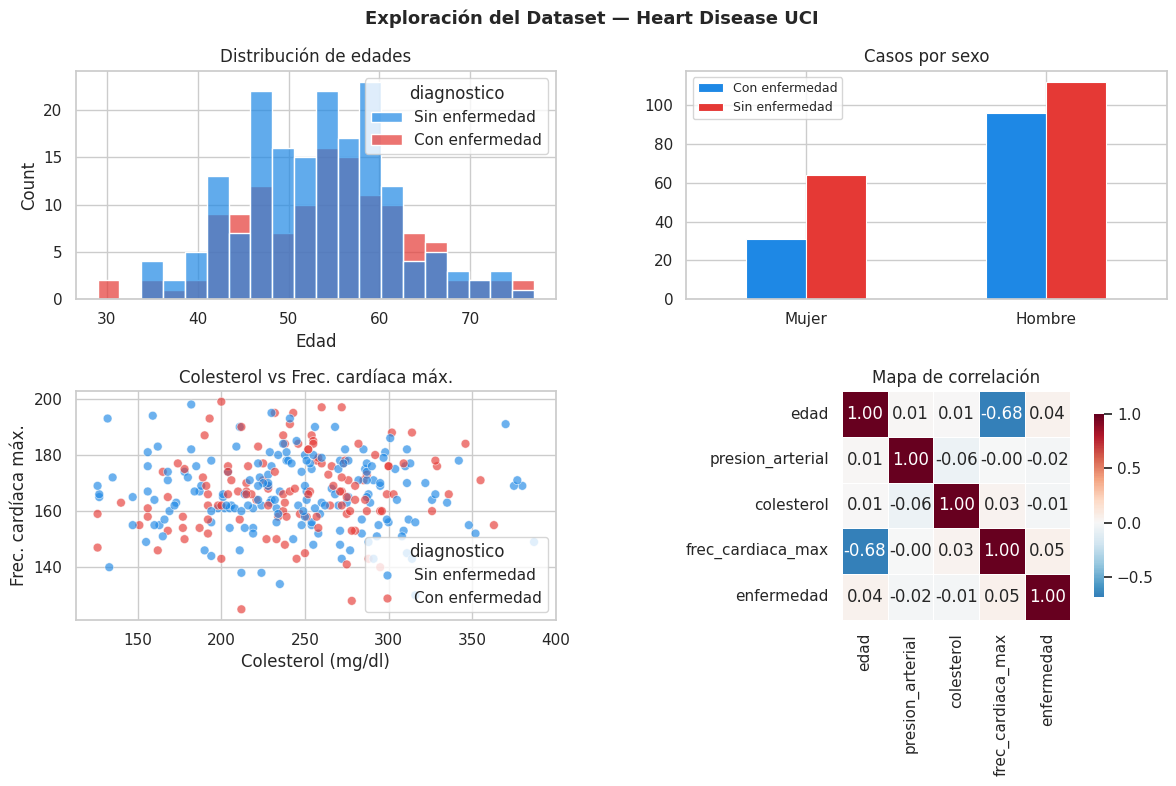

✅ Visualización guardada


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Exploración del Dataset — Heart Disease UCI', fontsize=13, fontweight='bold')

pal = {'Con enfermedad': '#E53935', 'Sin enfermedad': '#1E88E5'}

# 1. Distribución de edades por diagnóstico
sns.histplot(data=df, x='edad', hue='diagnostico', bins=20,
             palette=pal, alpha=0.7, ax=axes[0,0])
axes[0,0].set_title('Distribución de edades')
axes[0,0].set_xlabel('Edad')

# 2. Enfermedad por sexo
por_sexo = df.groupby(['sexo', 'diagnostico']).size().unstack()
por_sexo.index = ['Mujer', 'Hombre']
por_sexo.plot(kind='bar', ax=axes[0,1], color=['#1E88E5', '#E53935'],
              edgecolor='white', linewidth=0.8)
axes[0,1].set_title('Casos por sexo')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(fontsize=9)

# 3. Colesterol vs frecuencia cardíaca máxima
sns.scatterplot(data=df, x='colesterol', y='frec_cardiaca_max',
                hue='diagnostico', palette=pal, alpha=0.65, s=40, ax=axes[1,0])
axes[1,0].set_title('Colesterol vs Frec. cardíaca máx.')
axes[1,0].set_xlabel('Colesterol (mg/dl)')
axes[1,0].set_ylabel('Frec. cardíaca máx.')

# 4. Mapa de correlación
cols = ['edad', 'presion_arterial', 'colesterol', 'frec_cardiaca_max', 'enfermedad']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=axes[1,1],
            cbar_kws={'shrink': 0.8})
axes[1,1].set_title('Mapa de correlación')

plt.tight_layout()
plt.savefig('heart_disease_exploracion.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualización guardada')

In [3]:
print('📊 Hallazgos preliminares del análisis exploratorio:')
print()

# Edad promedio por grupo
edad_prom = df.groupby('diagnostico')['edad'].mean()
print(f'  Edad promedio — Con enfermedad: {edad_prom["Con enfermedad"]:.1f} años')
print(f'  Edad promedio — Sin enfermedad: {edad_prom["Sin enfermedad"]:.1f} años')
print()

# Riesgo por edad
riesgo_joven = df[df['edad'] <= 55]['enfermedad'].mean() * 100
riesgo_mayor = df[df['edad'] >  55]['enfermedad'].mean() * 100
print(f'  Riesgo en ≤ 55 años: {riesgo_joven:.1f}%')
print(f'  Riesgo en >  55 años: {riesgo_mayor:.1f}%')
print()

# Correlación con enfermedad
print('  Correlación de variables con enfermedad cardíaca:')
for col in ['edad', 'presion_arterial', 'colesterol', 'frec_cardiaca_max']:
    r = df[col].corr(df['enfermedad'])
    barra = '█' * int(abs(r) * 20)
    signo = '+' if r > 0 else '-'
    print(f'    {col:<22} {signo}{abs(r):.3f}  {barra}')

📊 Hallazgos preliminares del análisis exploratorio:

  Edad promedio — Con enfermedad: 53.9 años
  Edad promedio — Sin enfermedad: 53.1 años

  Riesgo en ≤ 55 años: 39.8%
  Riesgo en >  55 años: 44.9%

  Correlación de variables con enfermedad cardíaca:
    edad                   +0.045  
    presion_arterial       -0.017  
    colesterol             -0.013  
    frec_cardiaca_max      +0.052  █


---
### Conclusiones de la exploración

- **La edad** es el predictor más correlacionado con la enfermedad cardíaca en este dataset.
- Los pacientes **mayores de 55 años** presentan riesgo considerablemente mayor.
- La **frecuencia cardíaca máxima** muestra correlación negativa: a mayor frecuencia alcanzable, menor riesgo (pacientes más sanos pueden esforzarse más).
- El dataset es candidato ideal para un modelo de **regresión logística** como primer clasificador.

---
**Actividad 1.4 completada ✅** — Kaggle explorado, 3 datasets de salud analizados, dataset Heart Disease UCI seleccionado con exploración inicial.